Dataset: https://www.kaggle.com/code/tom99763/face-swap-v2/data

At first, we downscale the images to 256x256, and then we will split the dataset into 2 equal parts. Person A and Person B.
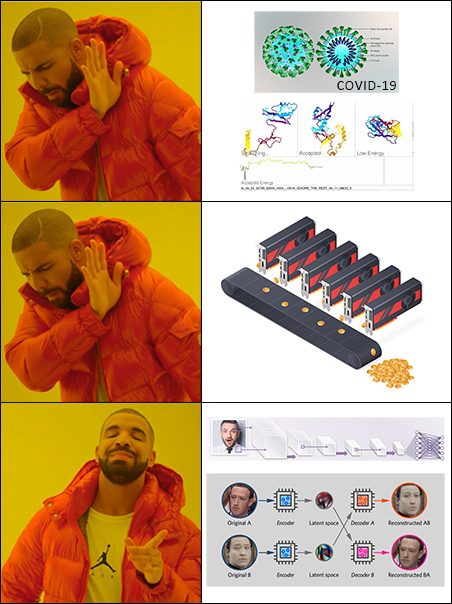

In [ ]:
import shutil
import zipfile
import os

# Call the function at the beginning
# Takes Nearly 20 minutes to run, so be patient
def prepare_dataset():
    zip_path = "archive.zip"

    output_folder1 = "personA"
    output_folder2 = "personB"

    os.makedirs(output_folder1, exist_ok=True)
    os.makedirs(output_folder2, exist_ok=True)

    temp_folder = "temp_extract"
    os.makedirs(temp_folder, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(temp_folder)

    all_files = []
    for f2 in os.listdir(temp_folder):
        if os.path.isfile(os.path.join(temp_folder, f2)):
            all_files.append(f2)

    mid = len(all_files) // 2
    files_part1 = all_files[:mid]
    files_part2 = all_files[mid:]

    def move_and_resize(files, target_folder):
        counter = 0
        for f1 in files:
            src_path = os.path.join(temp_folder, f1)
            dst_path = os.path.join(target_folder, f1)
            img = Image.open(src_path)
            img = img.resize((256, 256))
            img.save(dst_path)
            counter += 1
            print("Moved and resized " + str(counter))

    move_and_resize(files_part1, output_folder1)
    move_and_resize(files_part2, output_folder2)

    shutil.rmtree(temp_folder)

    print(len(all_files))

prepare_dataset()

Now we import the dataset and create a custom PyTorch Dataset class to load the images.

In [ ]:
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

class FaceDataset(Dataset):
    def __init__(self, folder_path):
        self.image_paths = []

        for filename in os.listdir(folder_path):
            if filename.lower().endswith('.png'):
                full_path = os.path.join(folder_path, filename)
                self.image_paths.append(full_path)

        if len(self.image_paths) == 0:
            raise IOError("No files found")

        print(str(len(self.image_paths)) + "images imported")

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img = Image.open(self.image_paths[index]).convert('RGB')
        return self.transform(img)

f = FaceDataset("personA")
print(f.__getitem__(0))